In [1]:
from IPython.display import Image
import xarray as xr
import numpy as np
import math
import cartopy.crs as ccrs # for geographic plotting
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from global_land_mask import globe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.cm as cm
from matplotlib.colors import to_hex
import glob
import os
import pandas as pd
import matplotlib.patches as mpatches


In [2]:
# --- 1. Définition des Chemins (Tes dictionnaires) ---

dict_sst = {
    "EC-Earth3": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3/piControl/r1i1p1f1/Omon/tos/gn/v20200918/",
    "EC-Earth3-Veg-LR": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3-Veg-LR/piControl/r1i1p1f1/Omon/tos/gn/v20200919/",
    #"EC-Earth3-CC": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3-CC/piControl/r1i1p1f1/Omon/tos/gn/v20210416/",
    #"IPSL-CM6A-LR": "/g/data/oi10/replicas/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/piControl/r1i1p1f1/Omon/tos/gn/v20181123/",
    #"CIESM":  "/g/data/oi10/replicas/CMIP6/CMIP/THU/CIESM/piControl/r1i1p1f1/Omon/tos/gn/v20200220/",
    "ACCESS-ESM1-5": "/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/piControl/r1i1p1f1/Omon/tos/gn/latest/",
    #"MCM-UA-1-0": "/g/data/oi10/replicas/CMIP6/CMIP/UA/MCM-UA-1-0/piControl/r1i1p1f1/Omon/tos/gn/v20190731/",
    "SAMO-UNICON": "/g/data/oi10/replicas/CMIP6/CMIP/SNU/SAM0-UNICON/piControl/r1i1p1f1/Omon/tos/gn/v20190910/", 
    "GFDL-ESM4": "/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/piControl/r1i1p1f1/Omon/tos/gr/v20180701/",
    "GFDL-CM4": "/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/piControl/r1i1p1f1/Omon/tos/gr/v20190201/",
    "NorESM2-MM": "/g/data/oi10/replicas/CMIP6/CMIP/NCC/NorESM2-MM/piControl/r1i1p1f1/Omon/tos/gn/v20191108/",
    #"NorESM2-LM": "/g/data/oi10/replicas/CMIP6/CMIP/NCC/NorESM2-LM/piControl/r1i1p1f1/Omon/tos/gn/v20210118/",
    #"NorCPM1": "/g/data/oi10/replicas/CMIP6/CMIP/NCC/NorCPM1/piControl/r1i1p1f1/Omon/tos/gn/v20190914/",
    #"CESM2": "/g/data/oi10/replicas/CMIP6/CMIP/NCAR/CESM2/piControl/r1i1p1f1/Omon/tos/gn/v20190320/",
    #"CESM2-WACCM": "/g/data/oi10/replicas/CMIP6/CMIP/NCAR/CESM2-WACCM/piControl/r1i1p1f1/Omon/tos/gn/v20190320/",
    #"CESM2-WACCM-FV2": "/g/data/oi10/replicas/CMIP6/CMIP/NCAR/CESM2-WACCM-FV2/piControl/r1i1p1f1/Omon/tos/gn/v20191120/",
    #"CESM2-FV2": "/g/data/oi10/replicas/CMIP6/CMIP/NCAR/CESM2-FV2/piControl/r1i1p1f1/Omon/tos/gn/v20191120/",
    #"GISS-E2-2-G": "/g/data/oi10/replicas/CMIP6/CMIP/NASA-GISS/GISS-E2-2-G/piControl/r1i1p1f1/Omon/tos/gn/v20191120/",    
    #"GISS-E2-1-H": "/g/data/oi10/replicas/CMIP6/CMIP/NASA-GISS/GISS-E2-1-H/piControl/r1i1p1f1/Omon/tos/gn/v20190410/",
    #"GISS-E2-1-G": "/g/data/oi10/replicas/CMIP6/CMIP/NASA-GISS/GISS-E2-1-G/piControl/r1i1p1f1/Omon/tos/gn/v20180824/",
    #"GISS-E2-1-G-CC": "/g/data/oi10/replicas/CMIP6/CMIP/NASA-GISS/GISS-E2-1-G-CC/piControl/r1i1p1f1/Omon/tos/gn/v20190815/",
    "MRI-ESM2-0": "/g/data/oi10/replicas/CMIP6/CMIP/MRI/MRI-ESM2-0/piControl/r1i1p1f1/Omon/tos/gn/v20190904/",
    #"MPI-ESM1-2-LR": "/g/data/oi10/replicas/CMIP6/CMIP/MPI-M/MPI-ESM1-2-LR/piControl/r1i1p1f1/Omon/tos/gn/v20190710/",
    #"MPI-ESM1-2-HR": "/g/data/oi10/replicas/CMIP6/CMIP/MPI-M/MPI-ESM1-2-HR/piControl/r1i1p1f1/Omon/tos/gn/v20190710/",
    #"ICON-ESM-LR": "/g/data/oi10/replicas/CMIP6/CMIP/MPI-M/ICON-ESM-LR/piControl/r1i1p1f1/Omon/tos/gn/v20210215/",
    "UKESM1-0-LL": "/g/data/oi10/replicas/CMIP6/CMIP/MOHC/UKESM1-0-LL/piControl/r1i1p1f2/Omon/tos/gn/v20200828/",
    "HadGEM3-GC31-LL": "/g/data/oi10/replicas/CMIP6/CMIP/MOHC/HadGEM3-GC31-LL/piControl/r1i1p1f1/Omon/tos/gn/v20190628/",
    #"MIROC6": "/g/data/oi10/replicas/CMIP6/CMIP/MIROC/MIROC6/piControl/r1i1p1f1/Omon/tos/gn/v20181212/",
    #"MIROC-ES2L": "/g/data/oi10/replicas/CMIP6/CMIP/MIROC/MIROC-ES2L/piControl/r1i1p1f2/Omon/tos/gn/v20190823/",
    #"CMCC-ESM2": "/g/data/oi10/replicas/CMIP6/CMIP/CMCC/CMCC-ESM2/piControl/r1i1p1f1/Omon/tos/gn/v20210304/",
    #"CMCC-CM2-SR5": "/g/data/oi10/replicas/CMIP6/CMIP/CMCC/CMCC-CM2-SR5/piControl/r1i1p1f1/Omon/tos/gn/v20200616/",
    #"CanESM5": "/g/data/oi10/replicas/CMIP6/CMIP/CCCma/CanESM5/piControl/r1i1p1f1/Omon/tos/gn/v20190429/",
    #"CAMS-CSM1-0": "/g/data/oi10/replicas/CMIP6/CMIP/CAMS/CAMS-CSM1-0/piControl/r1i1p1f1/Omon/tos/gn/v20190729/",
    #"BCC-ESM1": "/g/data/oi10/replicas/CMIP6/CMIP/BCC/BCC-ESM1/piControl/r1i1p1f1/Omon/tos/gn/v20181218/",
    #"BCC-CSM2-MR": "/g/data/oi10/replicas/CMIP6/CMIP/BCC/BCC-CSM2-MR/piControl/r1i1p1f1/Omon/tos/gn/v20181015/",
    #"AWI-ESM-1-1-LR": "/g/data/oi10/replicas/CMIP6/CMIP/AWI/AWI-ESM-1-1-LR/piControl/r1i1p1f1/Omon/tos/gn/v20200212/",
}

dict_pr = {
    "EC-Earth3": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3/piControl/r1i1p1f1/Amon/pr/gr/v20200312/",
    "EC-Earth3-Veg-LR": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3-Veg-LR/piControl/r1i1p1f1/Amon/pr/gr/v20200213/",
    #"EC-Earth3-CC": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3-CC/piControl/r1i1p1f1/Amon/pr/gr/v20210330/",
    #"IPSL-CM6A-LR": "/g/data/oi10/replicas/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/piControl/r1i1p1f1/Amon/pr/gr/v20200326/",
    #"CIESM":  "/g/data/oi10/replicas/CMIP6/CMIP/THU/CIESM/piControl/r1i1p1f1/Amon/pr/gr/v20200417/",
    "ACCESS-ESM1-5": "/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/piControl/r1i1p1f1/Amon/pr/gn/latest/",
    #"MCM-UA-1-0": "/g/data/oi10/replicas/CMIP6/CMIP/UA/MCM-UA-1-0/piControl/r1i1p1f1/Amon/pr/gn/v20191017/",
    "SAMO-UNICON": "/g/data/oi10/replicas/CMIP6/CMIP/SNU/SAM0-UNICON/piControl/r1i1p1f1/Amon/pr/gn/v20190910/",
    "GFDL-ESM4": "/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/piControl/r1i1p1f1/Amon/pr/gr1/v20180701/",
    "GFDL-CM4": "/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/piControl/r1i1p1f1/Amon/pr/gr1/v20180701/",
    "NorESM2-MM": "/g/data/oi10/replicas/CMIP6/CMIP/NCC/NorESM2-MM/piControl/r1i1p1f1/Amon/pr/gn/v20191108/",
    #"NorESM2-LM": "/g/data/oi10/replicas/CMIP6/CMIP/NCC/NorESM2-LM/piControl/r1i1p1f1/Amon/pr/gn/v20210118/",
    #"NorCPM1": "/g/data/oi10/replicas/CMIP6/CMIP/NCC/NorCPM1/piControl/r1i1p1f1/Amon/pr/gn/v20190914/",
    #"CESM2": "/g/data/oi10/replicas/CMIP6/CMIP/NCAR/CESM2/piControl/r1i1p1f1/Amon/pr/gn/v20190320/",
    #"CESM2-WACCM": "/g/data/oi10/replicas/CMIP6/CMIP/NCAR/CESM2-WACCM/piControl/r1i1p1f1/Amon/pr/gn/v20190320/",
    #"CESM2-WACCM-FV2": "/g/data/oi10/replicas/CMIP6/CMIP/NCAR/CESM2-WACCM-FV2/piControl/r1i1p1f1/Amon/pr/gn/v20191120/",
    #"CESM2-FV2": "/g/data/oi10/replicas/CMIP6/CMIP/NCAR/CESM2-FV2/piControl/r1i1p1f1/Amon/pr/gn/v20191120/",
    #"GISS-E2-2-G": "/g/data/oi10/replicas/CMIP6/CMIP/NASA-GISS/GISS-E2-2-G/piControl/r1i1p1f1/Amon/pr/gn/v20191120/",
    #"GISS-E2-1-H": "/g/data/oi10/replicas/CMIP6/CMIP/NASA-GISS/GISS-E2-1-H/piControl/r1i1p1f1/Amon/pr/gn/v20190410/",
    #"GISS-E2-1-G": "/g/data/oi10/replicas/CMIP6/CMIP/NASA-GISS/GISS-E2-1-G/piControl/r1i1p1f1/Amon/pr/gn/v20180824/",
    #"GISS-E2-1-G-CC": "/g/data/oi10/replicas/CMIP6/CMIP/NASA-GISS/GISS-E2-1-G-CC/piControl/r1i1p1f1/Amon/pr/gn/v20190815/",
    "MRI-ESM2-0": "/g/data/oi10/replicas/CMIP6/CMIP/MRI/MRI-ESM2-0/piControl/r1i1p1f1/Amon/pr/gn/v20190222/",
    #"MPI-ESM1-2-LR": "/g/data/oi10/replicas/CMIP6/CMIP/MPI-M/MPI-ESM1-2-LR/piControl/r1i1p1f1/Amon/pr/gn/v20190710/",
    #"MPI-ESM1-2-HR": "/g/data/oi10/replicas/CMIP6/CMIP/MPI-M/MPI-ESM1-2-HR/piControl/r1i1p1f1/Amon/pr/gn/v20190710/",
    #"ICON-ESM-LR": "/g/data/oi10/replicas/CMIP6/CMIP/MPI-M/ICON-ESM-LR/piControl/r1i1p1f1/Amon/pr/gn/v20210215/",
    "UKESM1-0-LL": "/g/data/oi10/replicas/CMIP6/CMIP/MOHC/UKESM1-0-LL/piControl/r1i1p1f2/Amon/pr/gn/v20200828/",
    "HadGEM3-GC31-LL": "/g/data/oi10/replicas/CMIP6/CMIP/MOHC/HadGEM3-GC31-LL/piControl/r1i1p1f1/Amon/pr/gn/v20190628/",
    #"MIROC6": "/g/data/oi10/replicas/CMIP6/CMIP/MIROC/MIROC6/piControl/r1i1p1f1/Amon/pr/gn/v20181212/",
    #"MIROC-ES2L": "/g/data/oi10/replicas/CMIP6/CMIP/MIROC/MIROC-ES2L/piControl/r1i1p1f2/Amon/pr/gn/v20190823/",
    #"CMCC-ESM2": "/g/data/oi10/replicas/CMIP6/CMIP/CMCC/CMCC-ESM2/piControl/r1i1p1f1/Amon/pr/gn/v20210304/",
    #"CMCC-CM2-SR5": "/g/data/oi10/replicas/CMIP6/CMIP/CMCC/CMCC-CM2-SR5/piControl/r1i1p1f1/Amon/pr/gn/v20200616/",
    #"CanESM5": "/g/data/oi10/replicas/CMIP6/CMIP/CCCma/CanESM5/piControl/r1i1p1f1/Amon/pr/gn/v20190429/",
    #"CAMS-CSM1-0": "/g/data/oi10/replicas/CMIP6/CMIP/CAMS/CAMS-CSM1-0/piControl/r1i1p1f1/Amon/pr/gn/v20190729/",
    #"BCC-ESM1": "/g/data/oi10/replicas/CMIP6/CMIP/BCC/BCC-ESM1/piControl/r1i1p1f1/Amon/pr/gn/v20181214/",
    #"BCC-CSM2-MR": "/g/data/oi10/replicas/CMIP6/CMIP/BCC/BCC-CSM2-MR/piControl/r1i1p1f1/Amon/pr/gn/v20181016/",
    #"AWI-ESM-1-1-LR": "/g/data/oi10/replicas/CMIP6/CMIP/AWI/AWI-ESM-1-1-LR/piControl/r1i1p1f1/Amon/pr/gn/v20200212/",
}

dict_sm = {
    "EC-Earth3": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3/piControl/r1i1p1f1/Lmon/mrso/gr/v20200312/",
    "EC-Earth3-Veg-LR": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3-Veg-LR/piControl/r1i1p1f1/Lmon/mrso/gr/v20201113/", 
    #"EC-Earth3-CC": "/g/data/oi10/replicas/CMIP6/CMIP/EC-Earth-Consortium/EC-Earth3-CC/piControl/r1i1p1f1/Lmon/mrso/gr/v20210114/",
    #"IPSL-CM6A-LR": "/g/data/oi10/replicas/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/piControl/r1i1p1f1/Lmon/mrso/gr/v20200326/",
    #"CIESM":  "/g/data/oi10/replicas/CMIP6/CMIP/THU/CIESM/piControl/r1i1p1f1/Lmon/mrso/gr/v20200417/",
    "ACCESS-ESM1-5": "/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/piControl/r1i1p1f1/Lmon/mrso/gn/latest/",
    #"MCM-UA-1-0": "/g/data/oi10/replicas/CMIP6/CMIP/UA/MCM-UA-1-0/piControl/r1i1p1f1/Lmon/mrso/gn/v20190731/",
    "SAMO-UNICON": "/g/data/oi10/replicas/CMIP6/CMIP/SNU/SAM0-UNICON/piControl/r1i1p1f1/Lmon/mrso/gn/v20190910/",
    "GFDL-ESM4": "/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/piControl/r1i1p1f1/Lmon/mrso/gr1/v20180701/",
    "GFDL-CM4": "/g/data/oi10/replicas/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/piControl/r1i1p1f1/Lmon/mrso/gr1/v20180701/",
    "NorESM2-MM": "/g/data/oi10/replicas/CMIP6/CMIP/NCC/NorESM2-MM/piControl/r1i1p1f1/Lmon/mrso/gn/v20191108/",
    #"NorESM2-LM": "/g/data/oi10/replicas/CMIP6/CMIP/NCC/NorESM2-LM/piControl/r1i1p1f1/Lmon/mrso/gn/v20210118/",
    #"NorCPM1": "/g/data/oi10/replicas/CMIP6/CMIP/NCC/NorCPM1/piControl/r1i1p1f1/Lmon/mrso/gn/v20190914/",
   # "CESM2": "/g/data/oi10/replicas/CMIP6/CMIP/NCAR/CESM2/piControl/r1i1p1f1/Lmon/mrso/gn/v20190320/",
    #"CESM2-WACCM": "/g/data/oi10/replicas/CMIP6/CMIP/NCAR/CESM2-WACCM/piControl/r1i1p1f1/Lmon/mrso/gn/v20190320/",
    #"CESM2-WACCM-FV2": "/g/data/oi10/replicas/CMIP6/CMIP/NCAR/CESM2-WACCM-FV2/piControl/r1i1p1f1/Lmon/mrso/gn/v20191120/",
    #"CESM2-FV2": "/g/data/oi10/replicas/CMIP6/CMIP/NCAR/CESM2-FV2/piControl/r1i1p1f1/Lmon/mrso/gn/v20191120/",
    #"GISS-E2-2-G": "/g/data/oi10/replicas/CMIP6/CMIP/NASA-GISS/GISS-E2-2-G/piControl/r1i1p1f1/Lmon/mrso/gn/v20191120/",
    #"GISS-E2-1-H": "/g/data/oi10/replicas/CMIP6/CMIP/NASA-GISS/GISS-E2-1-H/piControl/r1i1p1f1/Lmon/mrso/gn/v20190410/",
    #"GISS-E2-1-G": "/g/data/oi10/replicas/CMIP6/CMIP/NASA-GISS/GISS-E2-1-G/piControl/r1i1p1f1/Lmon/mrso/gn/v20180824/",
    #"GISS-E2-1-G-CC": "/g/data/oi10/replicas/CMIP6/CMIP/NASA-GISS/GISS-E2-1-G-CC/piControl/r1i1p1f1/Lmon/mrso/gn/v20190815/",
    "MRI-ESM2-0": "/g/data/oi10/replicas/CMIP6/CMIP/MRI/MRI-ESM2-0/piControl/r1i1p1f1/Lmon/mrso/gn/v20190603/",
    #"MPI-ESM1-2-LR": "/g/data/oi10/replicas/CMIP6/CMIP/MPI-M/MPI-ESM1-2-LR/piControl/r1i1p1f1/Lmon/mrso/gn/v20190710/",
    #"MPI-ESM1-2-HR": "/g/data/oi10/replicas/CMIP6/CMIP/MPI-M/MPI-ESM1-2-HR/piControl/r1i1p1f1/Lmon/mrso/gn/v20190710/",
    #"ICON-ESM-LR": "/g/data/oi10/replicas/CMIP6/CMIP/MPI-M/ICON-ESM-LR/piControl/r1i1p1f1/Lmon/mrso/gn/v20210215/",
    "UKESM1-0-LL": "/g/data/oi10/replicas/CMIP6/CMIP/MOHC/UKESM1-0-LL/piControl/r1i1p1f2/Lmon/mrso/gn/v20200828/",
    "HadGEM3-GC31-LL": "/g/data/oi10/replicas/CMIP6/CMIP/MOHC/HadGEM3-GC31-LL/piControl/r1i1p1f1/Lmon/mrso/gn/v20190628/",
    #"MIROC6": "/g/data/oi10/replicas/CMIP6/CMIP/MIROC/MIROC6/piControl/r1i1p1f1/Lmon/mrso/gn/v20190311/",
    #"MIROC-ES2L": "/g/data/oi10/replicas/CMIP6/CMIP/MIROC/MIROC-ES2L/piControl/r1i1p1f2/Lmon/mrso/gn/v20190823/",
    #"CMCC-ESM2": "/g/data/oi10/replicas/CMIP6/CMIP/CMCC/CMCC-ESM2/piControl/r1i1p1f1/Lmon/mrso/gn/v20210304/",
    #"CMCC-CM2-SR5": "/g/data/oi10/replicas/CMIP6/CMIP/CMCC/CMCC-CM2-SR5/piControl/r1i1p1f1/Lmon/mrso/gn/v20200616/",
    #"CanESM5": "/g/data/oi10/replicas/CMIP6/CMIP/CCCma/CanESM5/piControl/r1i1p1f1/Lmon/mrso/gn/v20190429/",
    #"CAMS-CSM1-0": "/g/data/oi10/replicas/CMIP6/CMIP/CAMS/CAMS-CSM1-0/piControl/r1i1p1f1/Lmon/mrso/gn/v20191212/",
    #"BCC-ESM1": "/g/data/oi10/replicas/CMIP6/CMIP/BCC/BCC-ESM1/piControl/r1i1p1f1/Lmon/mrso/gn/v20181211/",
    #"BCC-CSM2-MR": "/g/data/oi10/replicas/CMIP6/CMIP/BCC/BCC-CSM2-MR/piControl/r1i1p1f1/Lmon/mrso/gn/v20181012/",
    #"AWI-ESM-1-1-LR": "/g/data/oi10/replicas/CMIP6/CMIP/AWI/AWI-ESM-1-1-LR/piControl/r1i1p1f1/Lmon/mrso/gn/v20200212/",
}

# --- 2. Chargement du Catalogue ---
catalog = pd.read_csv('/g/data/m35/qr1706/PhD-1_CMIP_analysis/csv_npy/triple_lanina_catalog_sp.csv')
# On suppose que le catalogue a une colonne 'Model' et 'Year' (ou 'Start_Year')
#print("Modèles dans le catalogue :", catalog['model'].unique())

# --- 3. Définition des bornes géographiques ---
lat_b = (-23, -11) # Nord Australie
lon_b = (122, 149)

# --- 4. Fonction de Detrending (Même que pour les obs) ---
def apply_detrend(da_ts, window=240):
    # rolling avec min_periods=1 pour gérer les bords sans NaN excessifs au début
    moyenne_mobile = da_ts.rolling(time=window, center=True, min_periods=1).mean()
    da_detrended = da_ts - moyenne_mobile
    return da_detrended

print("Setup terminé.")

Setup terminé.


In [3]:
import glob

# On s'assure que les chemins finissent bien par un slash et on utilise glob pour lister les fichiers .nc
def get_files(path):
    files = glob.glob(os.path.join(path, "*.nc"))
    return sorted(files)

# On transforme tes dictionnaires de "chemins" en dictionnaires de "listes de fichiers"
dict_sst_files = {m: get_files(p) for m, p in dict_sst.items()}
dict_pr_files = {m: get_files(p) for m, p in dict_pr.items()}
dict_sm_files = {m: get_files(p) for m, p in dict_sm.items()}


In [4]:
def get_oni_noaa_style_piControl(da_weighted_mean):
    """Calcule l'ONI selon la méthodologie NOAA (30 ans glissants)."""
    anomalies = []
    time_coord = da_weighted_mean.time
    all_years = time_coord.dt.year.values
    unique_years = np.unique(all_years)
    first_yr, last_yr = unique_years[0], unique_years[-1]
    current_last_yr = first_yr
    all_spatial_composites = {} # Stockera [3_ans, lat, lon] pour chaque modèle

    for yr in range(first_yr + 15, last_yr - 14, 5):
        mask_period = (all_years >= yr) & (all_years <= yr + 4)
        mask_base = (all_years >= yr - 15) & (all_years <= yr + 14)
        data_slice = da_weighted_mean.isel(time=mask_period)
        base_slice = da_weighted_mean.isel(time=mask_base)
        if data_slice.size >= 60 and base_slice.size >= 360:
            anom = data_slice.groupby('time.month') - base_slice.groupby('time.month').mean(dim='time')
            anomalies.append(anom)
            current_last_yr = yr + 4

    if last_yr > current_last_yr:
        remainder_mask = (all_years > current_last_yr)
        base_end_mask = (all_years >= last_yr - 30) & (all_years <= last_yr)
        data_remainder = da_weighted_mean.isel(time=remainder_mask)
        base_end = da_weighted_mean.isel(time=base_end_mask)
        if data_remainder.size > 0 and base_end.size >= 360:
            anom_end = data_remainder.groupby('time.month') - base_end.groupby('time.month').mean(dim='time')
            anomalies.append(anom_end)
            
    if not anomalies: return None
    all_anom = xr.concat(anomalies, dim='time').sortby("time")
    all_anom = all_anom.sel(time=~all_anom.get_index("time").duplicated())
    return all_anom.rolling(time=3, center=True).mean().round(2)

def identify_triples_final(oni_da):
    """Identifie les Triple La Niña (seuil relatif 0.5*STD)."""
    std_val = float(oni_da.std())
    threshold = -0.5 * std_val
    is_lanina_month = (oni_da <= threshold)
    
    lanina_years = []
    all_years = np.unique(oni_da['time.year'])
    for yr in all_years[:-1]:
        mask_enso = ((oni_da['time.year'] == yr) & (oni_da['time.month'] >= 6)) | \
                    ((oni_da['time.year'] == yr + 1) & (oni_da['time.month'] <= 5))
        sub = is_lanina_month.where(mask_enso, drop=True)
        if len(sub) >= 12 and (sub.rolling(time=5).sum() >= 5).any():
            peak_months = [11, 12, 1, 2, 3]
            if is_lanina_month.where(mask_enso & oni_da['time.month'].isin(peak_months), drop=True).any():
                lanina_years.append(int(yr))
    
    triple_starts = []
    lanina_years = sorted(list(set(lanina_years)))
    for i in range(len(lanina_years) - 2):
        y0, y1, y2 = lanina_years[i], lanina_years[i+1], lanina_years[i+2]
        if (y1 == y0 + 1) and (y2 == y0 + 2):
            if (y0 - 1) not in lanina_years:
                triple_starts.append(y0)
    return triple_starts

In [5]:
def get_single_var_ts_final(model_name, var_type, triple_years):
    events = []
    baseline_raw = np.nan
    historical_clim_anom = None
    seasonal_climatology_abs = None
    
    try:
        print(f"DEBUG: Fonction get_single_var_ts_final appelée pour {model_name} {var_type}")

        # --- 1. SÉLECTION DES FICHIERS ---
        if var_type == 'pr':
            files = dict_pr_files.get(model_name)
            vname = 'pr'
        elif var_type == 'sm':
            files = dict_sm_files.get(model_name)
            vname = 'mrso'
        else:
            files = dict_sst_files.get(model_name)
            vname = 'tos'

        if not files or len(files) == 0:
            print(f"FAILED {model_name} {var_type}: Liste de fichiers vide dans le dictionnaire.")
            return [], np.nan, None, None

        # --- RANGES GÉOGRAPHIQUES (définies AVANT l'ouverture du dataset) ---
        lat_range = lat_b if var_type != 'sst' else (-5, 5)
        lon_range = lon_b if var_type != 'sst' else (-170, -120)

        def light_preprocess(ds):
            return ds[[vname]]

        # --- 2. OUVERTURE ---
        open_kwargs = {
            'chunks': {'time': 500},
            'decode_times': False,
            'preprocess': light_preprocess,
        }

        if model_name == 'CAMS-CSM1-0':
            ds = xr.open_mfdataset(files, combine='nested', concat_dim='time', **open_kwargs)
        else:
            ds = xr.open_mfdataset(files, combine='by_coords', **open_kwargs)

        if 'IPSL' in model_name:
            ds.time.attrs['units'] = "days since 1850-01-01 00:00:00"
            ds.time.attrs['calendar'] = 'proleptic_gregorian'

        ds = xr.decode_cf(ds, use_cftime=True)

        # --- DÉCALAGE DE TEMPS ---
        if ds.time.dt.year.min() > 2200:
            offset = ds.time.dt.year.min().values - 1900
            new_times = [t.replace(year=t.year - int(offset)) for t in ds.time.values]
            ds = ds.assign_coords(time=new_times)

        ds = standardize_coords(ds)
        da = ds[vname]

        # --- 3. CAS SPÉCIAL : GRILLE NON STRUCTURÉE (ncells) ---
        if 'ncells' in da.dims:
            lat_vec = ds['lat']
            lon_vec = (((ds['lon'] + 180) % 360) - 180)
            mask_geo = (lat_vec >= lat_range[0]) & (lat_vec <= lat_range[1]) & \
                       (lon_vec >= lon_range[0]) & (lon_vec <= lon_range[1])
            ts_raw = da.where(mask_geo).mean(dim='ncells').compute()

        else:
            # --- 4. FIX GRILLES CURVILIGNES (dims i/j) ---
            if 'i' in da.dims:
                lat_var = 'lat' if 'lat' in ds.coords else 'latitude'
                lon_var = 'lon' if 'lon' in ds.coords else 'longitude'
                actual_lat = ds[lat_var].mean(dim='i').values
                actual_lon = ds[lon_var].mean(dim='j').values
                da = da.rename({'i': 'longitude', 'j': 'latitude'})
                da = da.assign_coords(latitude=actual_lat, longitude=actual_lon)

            if da.longitude.max() > 180:
                da = da.assign_coords(longitude=(da.longitude + 180) % 360 - 180)

            # --- 5. MASQUAGE TERRE (PR uniquement) ---
            if var_type == 'pr':
                sm_ref_files = dict_sm_files.get(model_name)
                if sm_ref_files:
                    ds_sm_sample = xr.open_dataset(sm_ref_files[0], decode_times=False).isel(time=0)
                    ds_sm_sample = standardize_coords(ds_sm_sample)
                    problematic_models = ['SAMO-UNICON', 'NorESM2-LM', 'NorESM2-MM']
                    if model_name not in problematic_models:
                        da = da.where(ds_sm_sample.mrso.notnull())

            # --- 6. MOYENNE SPATIALE ---
            geo_mask = (da.latitude >= lat_range[0]) & (da.latitude <= lat_range[1]) & \
                       (da.longitude >= lon_range[0]) & (da.longitude <= lon_range[1])
            spatial_dims = [d for d in da.dims if d != 'time']
            ts_raw = da.where(geo_mask).mean(dim=spatial_dims).compute()

        ds.close()

        # --- 7. CONVERSIONS ---
        if var_type == 'pr':
            ts_raw = ts_raw * 86400 * 30.44
        if var_type == 'sst' and ts_raw.mean() > 200:
            ts_raw = ts_raw - 273.15

        # --- 8. BASELINE ET CLIMATOLOGIE BRUTE (avant detrending) ---
        baseline_raw = ts_raw.mean().item()
        seasonal_climatology_abs = ts_raw.groupby('time.month').mean().compute()

        # --- 9. DETRENDING ---
        ts_anom = apply_detrend(ts_raw)

        # --- 10. CLIMATOLOGIE HISTORIQUE SUR SÉRIE DETRENDED ---
        # C'est cette variable (historical_clim_anom) qui sera utilisée
        # comme référence dans le plot — elle est centrée autour de 0
        historical_clim_anom = ts_anom.groupby('time.month').mean().compute()

        # --- 11. EXTRACTION ÉVÉNEMENTS ---
        for yr in triple_years:
            t_mask = (ts_anom.time.dt.year == yr) & (ts_anom.time.dt.month == 6)
            if t_mask.any():
                idx = int(np.where(t_mask)[0][0])
                if len(ts_anom.isel(time=slice(idx, idx + 36))) == 36:
                    events.append(
                        ts_anom.isel(time=slice(idx, idx + 36))
                               .assign_coords(time=np.arange(36))
                    )

        print(f"✅ {model_name} {var_type}: {len(events)} événements extraits.")
        return events, baseline_raw, historical_clim_anom, seasonal_climatology_abs

    except Exception as e:
        print(f"❌ FAILED {model_name} {var_type}: {e}")
        return [], np.nan, None, None

In [6]:
import calendar

# --- DÉFINITION DES MODÈLES COMMUNS ---
common_models = sorted(set(dict_sst_files.keys()) & set(dict_pr_files.keys()) & set(dict_sm_files.keys()))
print(f"Modèles communs ({len(common_models)}) : {common_models}")

# --- INITIALISATION ---
all_cmip_triples = {}
all_cmip_oni_objects = {}

for name in common_models:
    path = dict_sst_files.get(name)
    print(f"\n--- Processing {name} ---")
    
    try:
        # 1. Ouverture (use_cftime est crucial pour les calendriers non-standard)
        ds = xr.open_mfdataset(path, combine='by_coords', chunks={'time': 500}, use_cftime=True)
        
        # 2. Détection des noms et dimensions
        lat_n = next((c for c in ['nav_lat', 'lat', 'latitude'] if c in ds.coords or c in ds.data_vars), None)
        lon_n = next((c for c in ['nav_lon', 'lon', 'longitude'] if c in ds.coords or c in ds.data_vars), None)
        
        # On détecte les dimensions spatiales de 'tos' (ex: ['lat', 'lon'] pour GFDL)
        spatial_dims = [d for d in ds.tos.dims if d != 'time']
        
        # 3. Masquage Niño 3.4
        lon_sample = float(ds[lon_n].max())
        l1, l2 = (190, 240) if lon_sample > 180 else (-170, -120)
        mask_nino = ((ds[lat_n] >= -5) & (ds[lat_n] <= 5) & (ds[lon_n] >= l1) & (ds[lon_n] <= l2)).compute()
        
        # 4. CALCUL DES POIDS (L'astuce est ici : on reste simple)
        # On ne fait pas de .where() sur les poids, on garde le cos(lat) complet.
        weights = np.cos(np.deg2rad(ds[lat_n]))
        
        # 5. EXTRACTION DE LA SÉRIE NIÑO 3.4
        # On applique le masque uniquement sur les données. 
        # weighted() gérera automatiquement l'alignement des dimensions.
        ts = ds.tos.where(mask_nino).weighted(weights).mean(dim=spatial_dims).compute()
        
        # Conversion Celsius
        if ts.mean() > 100: ts = ts - 273.15
        
        # 6. CALCUL ONI & TRIPLES
        oni = get_oni_noaa_style_piControl(ts)
        
        if oni is not None:
            all_cmip_oni_objects[name] = oni
            
            # --- STATISTIQUES DEMANDÉES ---
            # STD Globale
            std_globale = float(oni.std())
            
            # Mois de variabilité maximale (Phase Locking)
            monthly_std = oni.groupby('time.month').std()
            max_idx = int(monthly_std.argmax()) + 1 # Jan=1
            max_val = float(monthly_std.max())
            month_name = calendar.month_name[max_idx][:3]
            
            # Détection des triples
            triples = identify_triples_final(oni)
            all_cmip_triples[name] = triples

            # --- AFFICHAGE ---
            years = oni['time.year'].values
            print(f"📊 Stats pour {name}:")
            print(f"   - Période: {years[0]} à {years[-1]} ({years[-1]-years[0]} ans)")
            print(f"   - ONI STD moyenne (globale): {std_globale:.3f} °C")
            print(f"   - Pic de variabilité: {month_name} ({max_val:.3f} °C)")
            print(f"   - Nombre de Triple La Niña: {len(triples)}")

        ds.close()
        
    except Exception as e:
        print(f"💥 Erreur sur {name}: {e}")

print("\nTraitement terminé.")

Modèles communs (10) : ['ACCESS-ESM1-5', 'EC-Earth3', 'EC-Earth3-Veg-LR', 'GFDL-CM4', 'GFDL-ESM4', 'HadGEM3-GC31-LL', 'MRI-ESM2-0', 'NorESM2-MM', 'SAMO-UNICON', 'UKESM1-0-LL']

--- Processing ACCESS-ESM1-5 ---
📊 Stats pour ACCESS-ESM1-5:
   - Période: 116 à 1100 (984 ans)
   - ONI STD moyenne (globale): 0.773 °C
   - Pic de variabilité: Jan (0.940 °C)
   - Nombre de Triple La Niña: 10

--- Processing EC-Earth3 ---
📊 Stats pour EC-Earth3:
   - Période: 2274 à 2759 (485 ans)
   - ONI STD moyenne (globale): 0.678 °C
   - Pic de variabilité: Dec (0.852 °C)
   - Nombre de Triple La Niña: 8

--- Processing EC-Earth3-Veg-LR ---
📊 Stats pour EC-Earth3-Veg-LR:
   - Période: 2315 à 2800 (485 ans)
   - ONI STD moyenne (globale): 0.620 °C
   - Pic de variabilité: Dec (0.809 °C)
   - Nombre de Triple La Niña: 7

--- Processing GFDL-CM4 ---
📊 Stats pour GFDL-CM4:
   - Période: 166 à 650 (484 ans)
   - ONI STD moyenne (globale): 0.797 °C
   - Pic de variabilité: Nov (1.002 °C)
   - Nombre de Triple L

In [7]:
def standardize_coords(ds):
    """
    Renames coordinates safely. If coords are 2D (curvilinear), 
    we avoid sorting as it breaks the grid structure.
    """
    rename_dict = {}
    for k in ds.coords:
        if k in ['nav_lat', 'lat']: rename_dict[k] = 'latitude'
        if k in ['nav_lon', 'lon']: rename_dict[k] = 'longitude'
    
    ds = ds.rename(rename_dict)
    
    # Only sort and wrap longitude if it's a 1D dimension (Regular Grid)
    if 'longitude' in ds.dims and ds.longitude.ndim == 1:
        if ds.longitude.max() > 180:
            ds.coords['longitude'] = (ds.coords['longitude'] + 180) % 360 - 180
            ds = ds.sortby('longitude')
        if 'latitude' in ds.dims and ds.latitude.ndim == 1:
            ds = ds.sortby('latitude')
            
    return ds

def get_regional_ts(da, lat_range, lon_range):
    """Calcule la moyenne spatiale pondérée (cosinus lat) sur une zone."""
    # Masque spatial
    mask = (da.latitude >= lat_range[0]) & (da.latitude <= lat_range[1]) & \
           (da.longitude >= lon_range[0]) & (da.longitude <= lon_range[1])
    
    # Calcul des poids (cosinus de la latitude)
    weights = np.cos(np.deg2rad(da.latitude))
    
    # On identifie les dimensions spatiales dynamiquement (x/y ou lat/lon)
    spatial_dims = [d for d in da.dims if d != 'time']
    
    # Moyenne pondérée sur le masque
    return da.where(mask).weighted(weights.fillna(0)).mean(dim=spatial_dims).compute()

def get_model_composite(model_name, triple_years):
    print(f"--- Processing {model_name} ---")
    try:
        # 1. Chargeur interne
        def robust_load(path, var_name):
            # Ajout du "/" final au cas où
            full_path = path if path.endswith('/') else path + '/'
            ds_raw = xr.open_mfdataset(full_path + "*.nc", chunks={'time': 120}, 
                                      combine='by_coords', decode_times=False, preprocess=light_preprocess)
            
            if model_name in ['IPSL-CM6A-LR', 'IPSL-CM5A2-INCA']:
                ds_raw.time.attrs['units'] = "days since 1850-01-01 00:00:00"
                ds_raw.time.attrs['calendar'] = 'proleptic_gregorian'
            
            if 'calendar' not in ds_raw.time.attrs:
                ds_raw.time.attrs['calendar'] = 'standard'
                
            ds_decoded = xr.decode_cf(ds_raw, use_cftime=True)
            return standardize_coords(ds_decoded)[var_name]

        # 2. Chargement des DataArrays
        pr = robust_load(dict_pr[model_name], 'pr')
        sm = robust_load(dict_sm[model_name], 'mrso')
        sst = robust_load(dict_sst[model_name], 'tos')

        # 3. Extraction des séries temporelles (Utilise la fonction globale)
        # Précipitations (mm/s -> mm/mois)
        pr_ts = get_regional_ts(pr, lat_b, lon_b) * 86400 * 30.44
        # Soil Moisture
        sm_ts = get_regional_ts(sm, lat_b, lon_b)
        # ONI (Niño 3.4) : zone standard (-170, -120)
        sst_ts = get_regional_ts(sst, (-5, 5), (-170, -120))
        
        if sst_ts.mean() > 200: sst_ts = sst_ts - 273.15
        
        # 4. Baselines (Moyennes historiques)
        baseline_pr = pr_ts.mean().item()
        baseline_sm = sm_ts.mean().item()
        
        # 5. Detrending (Assure-toi que apply_detrend existe dans ton environnement)
        pr_anom = apply_detrend(pr_ts)
        sm_anom = apply_detrend(sm_ts)
        oni_anom = apply_detrend(sst_ts)

        # 6. Découpage des événements de 36 mois
        ev_pr, ev_sm, ev_oni = [], [], []
        for yr in triple_years:
            time_mask = (pr_anom.time.dt.year == yr) & (pr_anom.time.dt.month == 6)
            if not time_mask.any(): continue
            
            idx = int(np.where(time_mask)[0][0])
            s = slice(idx, idx + 36)
            
            # On vérifie qu'on a bien 36 mois de données disponibles
            if len(pr_anom.isel(time=s)) == 36:
                # On réinitialise l'axe temps de 0 à 35 pour la concaténation future
                t_axis = np.arange(36)
                ev_pr.append(pr_anom.isel(time=s).assign_coords(time=t_axis))
                ev_sm.append(sm_anom.isel(time=s).assign_coords(time=t_axis))
                ev_oni.append(oni_anom.isel(time=s).assign_coords(time=t_axis))
        
        print(f"   -> Succès : {len(ev_pr)} événements trouvés.")
        return ev_pr, ev_sm, ev_oni, baseline_pr, baseline_sm

    except Exception as e:
        print(f"❌ ÉCHEC pour {model_name}: {e}")
        return None, None, None, None, None

In [8]:
results_pr, clims_pr, seasonal_abs_pr = {}, {}, {}
results_sm, clims_sm, seasonal_abs_sm = {}, {}, {}
results_oni = {}

for name in all_cmip_triples.keys():
    triples_years = all_cmip_triples[name]
    if len(triples_years) == 0:
        continue
    
    print(f"--- Processing {name} ---")
    
    # PR
    ev_p, _, clim_p, seas_p = get_single_var_ts_final(name, 'pr', triples_years)
    if ev_p:
        results_pr[name] = ev_p
        clims_pr[name] = clim_p
        seasonal_abs_pr[name] = seas_p

    # SM
    ev_s, _, clim_s, seas_s = get_single_var_ts_final(name, 'sm', triples_years)
    if ev_s:
        results_sm[name] = ev_s
        clims_sm[name] = clim_s
        seasonal_abs_sm[name] = seas_s

    # ONI : déjà calculé, on récupère directement et on découpe les événements
    if name in all_cmip_oni_objects:
        oni_full = all_cmip_oni_objects[name]
        oni_anom = apply_detrend(oni_full)
        ev_o = []
        for yr in triples_years:
            t_mask = (oni_anom.time.dt.year == yr) & (oni_anom.time.dt.month == 6)
            if not t_mask.any():
                continue
            idx = int(np.where(t_mask)[0][0])
            s = slice(idx, idx + 36)
            if len(oni_anom.isel(time=s)) == 36:
                ev_o.append(oni_anom.isel(time=s).assign_coords(time=np.arange(36)))
        if ev_o:
            results_oni[name] = ev_o

print("\n--- All composites extracted and ready for MMM plotting ---")

--- Processing ACCESS-ESM1-5 ---
DEBUG: Fonction get_single_var_ts_final appelée pour ACCESS-ESM1-5 pr


/home/561/qr1706/.local/lib/python3.9/site-packages/xarray/core/indexing.py:1617: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


✅ ACCESS-ESM1-5 pr: 10 événements extraits.
DEBUG: Fonction get_single_var_ts_final appelée pour ACCESS-ESM1-5 sm


/home/561/qr1706/.local/lib/python3.9/site-packages/xarray/core/indexing.py:1617: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


✅ ACCESS-ESM1-5 sm: 10 événements extraits.
--- Processing EC-Earth3 ---
DEBUG: Fonction get_single_var_ts_final appelée pour EC-Earth3 pr


...

✅ SAMO-UNICON sm: 18 événements extraits.
--- Processing UKESM1-0-LL ---
DEBUG: Fonction get_single_var_ts_final appelée pour UKESM1-0-LL pr


/home/561/qr1706/.local/lib/python3.9/site-packages/xarray/core/indexing.py:1617: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


✅ UKESM1-0-LL pr: 36 événements extraits.
DEBUG: Fonction get_single_var_ts_final appelée pour UKESM1-0-LL sm


/home/561/qr1706/.local/lib/python3.9/site-packages/xarray/core/indexing.py:1617: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


✅ UKESM1-0-LL sm: 36 événements extraits.

--- All composites extracted and ready for MMM plotting ---


In [9]:
# --- 1. REGROUPEMENT ET STATISTIQUES ---
all_pr = [ev for model_list in results_pr.values() for ev in model_list]
all_sm = [ev for model_list in results_sm.values() for ev in model_list]
all_oni = [ev for model_list in results_oni.values() for ev in model_list]

if len(all_pr) == 0:
    print("Erreur : Aucun événement n'a été chargé.")
else:
    da_pr = xr.concat(all_pr, dim='event')
    da_sm = xr.concat(all_sm, dim='event')
    da_oni = xr.concat(all_oni, dim='event')

    # --- 2. MMM DES ANOMALIES ---
    mmm_pr = da_pr.mean(dim='event').values
    mmm_sm = da_sm.mean(dim='event').values
    mmm_oni = da_oni.mean(dim='event').values

    # --- 3. RECONSTRUCTION DE LA CLIMATOLOGIE SUR 36 MOIS ---
    # Moyenne multi-modèles des climatologies mensuelles (shape: 12)
    mmm_clim_pr = xr.concat(list(clims_pr.values()), dim='model').mean(dim='model')
    mmm_clim_sm = xr.concat(list(clims_sm.values()), dim='model').mean(dim='model')

    # On commence en Juin (mois 6, index 5) et on tourne sur 36 mois
    # Les mois de départ : J(5) J(6) A(7) S(8) O(9) N(10) D(11) J(0) F(1)...
    start_month_idx = 5  # Juin = index 5 (Jan=0)
    month_indices_36 = [(start_month_idx + i) % 12 for i in range(36)]
    
# Reconstruction sur 36 mois à partir de Juin (index 5)
    clim_pr_36 = np.tile(np.roll(mmm_clim_pr.values, -5), 3)
    clim_sm_36 = np.tile(np.roll(mmm_clim_sm.values, -5), 3)

    # --- 4. SIGNAL TOTAL = ANOMALIE MMM + CLIMATOLOGIE ---
    mmm_pr_total = (mmm_pr + clim_pr_36)
    mmm_sm_total = (mmm_sm + clim_sm_36)

    # --- 5. INTERVALLES DE CONFIANCE (sur les anomalies + clim) ---
    ci_pr = [da_pr.quantile(0.05, dim='event').values + (clim_pr_36),
             da_pr.quantile(0.95, dim='event').values + (clim_pr_36)]
    ci_sm = [da_sm.quantile(0.05, dim='event').values + (clim_sm_36),
             da_sm.quantile(0.95, dim='event').values + (clim_sm_36)]
    ci_oni = [da_oni.quantile(0.05, dim='event'), da_oni.quantile(0.95, dim='event')]

In [10]:
# --- 1. REGROUPEMENT ET CALCUL DES ANOMALIES PAR MODÈLE ---
model_anoms_pr = []
model_anoms_sm = []
model_means_oni = [] # L'ONI est déjà une anomalie

for name in results_pr.keys():
    # 1a. Moyenne des événements pour CE modèle spécifique (Signal Total)
    m_pr_total = xr.concat(results_pr[name], dim='event').mean('event')
    m_sm_total = xr.concat(results_sm[name], dim='event').mean('event')
    m_oni = xr.concat(results_oni[name], dim='event').mean('event')
    
    # 1b. On récupère la climatologie de CE modèle et on la projette sur 36 mois
    # On suppose que clims_pr[name] est un tableau de 12 mois
    clim_pr_mod = np.tile(np.roll(clims_pr[name], -5), 3)
    clim_sm_mod = np.tile(np.roll(clims_sm[name], -5), 3)
    
    # 1c. ON CALCULE L'ANOMALIE POUR CE MODÈLE (Total - Sa propre clim)
    m_pr_anom = m_pr_total - clim_pr_mod
    m_sm_anom = m_sm_total - clim_sm_mod
    
    # On stocke les ANOMALIES pures
    model_anoms_pr.append(m_pr_anom)
    model_anoms_sm.append(m_sm_anom)
    model_means_oni.append(m_oni)

# --- 2. CRÉATION DES DATA-ARRAYS (Axe 'model') ---
# Maintenant, ce sont des tableaux d'ANOMALIES (centrés sur 0 pour chaque modèle)
da_anom_pr = xr.concat(model_anoms_pr, dim='model')
da_anom_sm = xr.concat(model_anoms_sm, dim='model')
da_mmm_oni = xr.concat(model_means_oni, dim='model')

# --- 3. CALCUL DU MMM ET DES INTERVALLES (Sur les anomalies pures) ---

# La ligne centrale du graphique (Multi-Model Mean des anomalies)
mmm_pr_anom = da_anom_pr.mean(dim='model').values
mmm_sm_anom = da_anom_sm.mean(dim='model').values
mmm_oni = da_mmm_oni.mean(dim='model').values

# Le Shading (Quantiles calculés sur les anomalies)
ci_pr_anom = [da_anom_pr.quantile(0.1, dim='model').values,
              da_anom_pr.quantile(0.9, dim='model').values]

ci_sm_anom = [da_anom_sm.quantile(0.1, dim='model').values,
              da_anom_sm.quantile(0.9, dim='model').values]

ci_oni = [da_mmm_oni.quantile(0.1, dim='model').values,
          da_mmm_oni.quantile(0.9, dim='model').values]

In [11]:
# --- 1. CALCUL DES ANOMALIES PAR MODÈLE ---
model_anoms_pr = []
model_anoms_sm = []

for name in results_pr.keys():
    # Signal total du modèle
    mmm_pr_total = xr.concat(model_means_pr, dim='model').mean('model').values
    mmm_sm_total = xr.concat(model_means_sm, dim='model').mean('model').values
    mmm_oni = xr.concat(model_means_oni, dim='model').mean('model').values
    
    # Sa propre climatologie (alignée sur Juin, 36 mois)
    c_pr_mod = np.tile(np.roll(clims_pr[name], -5), 3)
    c_sm_mod = np.tile(np.roll(clims_sm[name], -5), 3)
    
    # Anomalie pure pour ce modèle
    model_anoms_pr.append(m_pr_total - c_pr_mod)
    model_anoms_sm.append(m_sm_total - c_sm_mod)

# --- 2. RECONSTRUCTION DU SIGNAL TOTAL "PROPRE" POUR LE SHADING ---
# On convertit en DataArray
da_anom_pr = xr.concat(model_anoms_pr, dim='model')
da_anom_sm = xr.concat(model_anoms_sm, dim='model')

# On rajoute la climatologie MOYENNE (MMM) aux anomalies de chaque modèle
# Cela décale toutes les anomalies vers le haut (~150mm) sans changer leur écart
da_total_clean_pr = da_anom_pr + clim_pr_36
da_total_clean_sm = da_anom_sm + clim_sm_36

# --- 3. CALCUL DES QUANTILES POUR LE PLOT ---
ci_pr_low, ci_pr_high = da_total_clean_pr.quantile(0.1, 'model').values, da_total_clean_pr.quantile(0.9, 'model').values
ci_sm_low, ci_sm_high = da_total_clean_sm.quantile(0.1, 'model').values, da_total_clean_sm.quantile(0.9, 'model').values

NameError: name 'model_means_pr' is not defined

In [ ]:
# --- MÉTHODE DE RECENTRAGE (ALIGNEMENT DES ENVELOPPES) ---

def get_clean_bounds(results_dict, mmm_total):
    all_model_deviations = []
    
    for name in results_dict.keys():
        # 1. Moyenne du modèle (Signal Total)
        m_total = xr.concat(results_dict[name], dim='event').mean('event')
        # 2. Sa déviation par rapport à sa propre moyenne sur 36 mois
        # (On centre chaque modèle sur 0 temporairement)
        deviation = m_total - m_total.mean() 
        all_model_deviations.append(deviation)
    
    # 3. On crée le DataArray des déviations
    da_dev = xr.concat(all_model_deviations, dim='model')
    
    # 4. On recalcule les quantiles de ces déviations et on les ajoute au MMM TOTAL
    # C'est ce qui permet de "coller" l'enveloppe à la courbe mmm_pr_total
    low = mmm_total + (da_dev.quantile(0.1, dim='model').values - da_dev.mean(dim='model').values)
    high = mmm_total + (da_dev.quantile(0.9, dim='model').values - da_dev.mean(dim='model').values)
    
    return low, high

# --- APPLICATION ---
ci_pr_low, ci_pr_high = get_clean_bounds(results_pr, mmm_pr_total)
ci_sm_low, ci_sm_high = get_clean_bounds(results_sm, mmm_sm_total)

## Cellules a garder (normalement doit suffir)

In [12]:
# --- 1. MOYENNES PAR MODÈLE ---
model_means_pr = []
model_means_sm = []
model_means_oni = []

for name in results_pr.keys():
    model_means_pr.append(xr.concat(results_pr[name], dim='event').mean('event'))
    model_means_sm.append(xr.concat(results_sm[name], dim='event').mean('event'))
    model_means_oni.append(xr.concat(results_oni[name], dim='event').mean('event'))

# --- 2. CALCUL DU MMM TOTAL ---
mmm_pr_total = xr.concat(model_means_pr, dim='model').mean('model').values
mmm_sm_total = xr.concat(model_means_sm, dim='model').mean('model').values
mmm_oni = xr.concat(model_means_oni, dim='model').mean('model').values

# --- 3. RECONSTRUCTION DE LA CLIMATOLOGIE MMM ---
mmm_clim_pr = xr.concat(list(clims_pr.values()), dim='model').mean(dim='model')
mmm_clim_sm = xr.concat(list(clims_sm.values()), dim='model').mean(dim='model')

# Alignement sur Juin (index 5) sur 36 mois
clim_pr_36 = np.tile(np.roll(mmm_clim_pr.values, -5), 3)
clim_sm_36 = np.tile(np.roll(mmm_clim_sm.values, -5), 3)

In [13]:
# --- MÉTHODE DE RECENTRAGE ---
def get_clean_bounds(results_dict, mmm_total):
    all_model_deviations = []
    for name in results_dict.keys():
        m_total = xr.concat(results_dict[name], dim='event').mean('event')
        # On centre chaque modèle sur sa propre moyenne pour isoler la réponse au Niña
        deviation = m_total - m_total.mean() 
        all_model_deviations.append(deviation)
    
    da_dev = xr.concat(all_model_deviations, dim='model')
    
    # On applique les quantiles de la déviation sur la moyenne MMM
    low = mmm_total + (da_dev.quantile(0.1, dim='model').values - da_dev.mean(dim='model').values)
    high = mmm_total + (da_dev.quantile(0.9, dim='model').values - da_dev.mean(dim='model').values)
    return low, high

# --- CALCUL DES BORNES POUR LE PLOT ---
ci_pr_low, ci_pr_high = get_clean_bounds(results_pr, mmm_pr_total)
ci_sm_low, ci_sm_high = get_clean_bounds(results_sm, mmm_sm_total)

# Pour l'ONI (simple quantile car c'est déjà une anomalie)
da_oni = xr.concat(model_means_oni, dim='model')
ci_oni_low = da_oni.quantile(0.1, dim='model').values
ci_oni_high = da_oni.quantile(0.9, dim='model').values

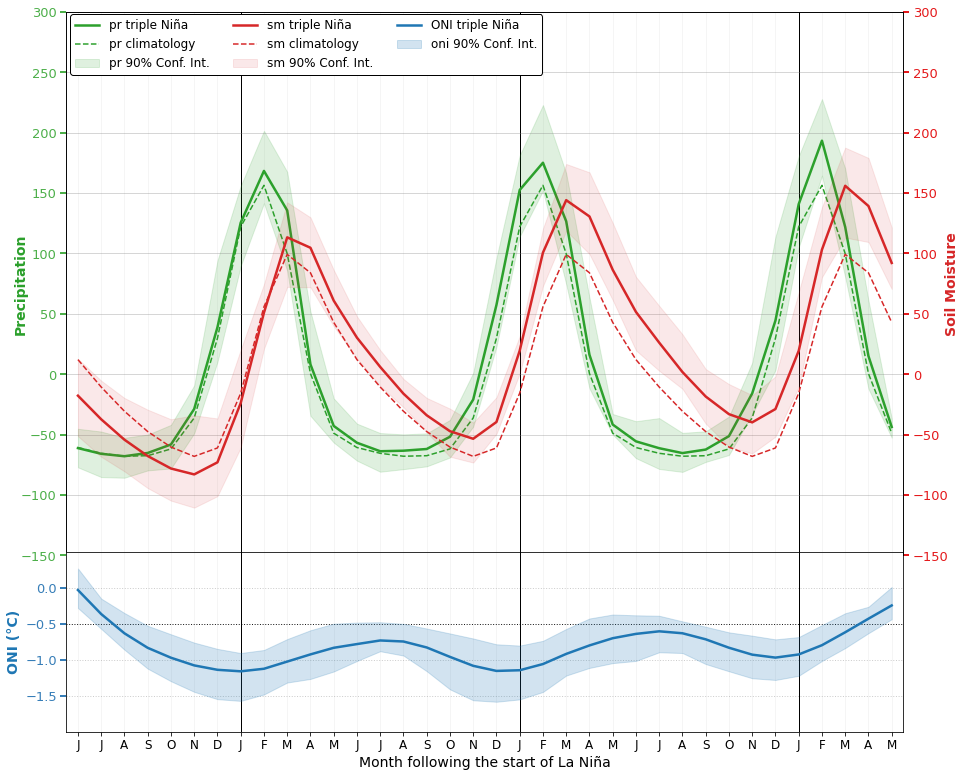

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- 5. FIGURE ---
fig, ax1 = plt.subplots(figsize=(15, 10))
x = np.arange(36)
months_labels = ['J','J','A','S','O','N','D','J','F','M','A','M'] * 3
color_sm = '#e41a1c'
color_pr = '#4daf4a'
color_oni = '#377eb8'

ax2 = ax1.twinx()

# --- DÉFINITION DE AX3 (L'axe manquant) ---
pos = ax1.get_position()
# On crée l'axe ax3 en dessous de ax1
ax3 = fig.add_axes([pos.x0, -0.12, pos.width, 0.25])

# --- PRÉCIPITATIONS (ax1) ---
ax1.fill_between(x, ci_pr_low, ci_pr_high, color='tab:green', alpha=0.15, zorder=1)
line_pr_tot, = ax1.plot(x, mmm_pr_total, color='tab:green', linestyle='-', 
                        linewidth=2.5, label='pr triple Niña', zorder=3)
line_pr_clim, = ax1.plot(x, clim_pr_36, color='tab:green', linestyle='--', 
                         linewidth=1.5, label='pr climatology', zorder=2)

# --- SOIL MOISTURE (ax2) ---
ax2.fill_between(x, ci_sm_low, ci_sm_high, color='tab:red', alpha=0.1, zorder=1)
line_sm_tot, = ax2.plot(x, mmm_sm_total, color='tab:red', linestyle='-', 
                        linewidth=2.5, label='sm triple Niña', zorder=3)
line_sm_clim, = ax2.plot(x, clim_sm_36, color='tab:red', linestyle='--', 
                         linewidth=1.5, label='sm climatology', zorder=2)

# --- ONI (ax3) ---
ax3.fill_between(x, ci_oni_low, ci_oni_high, color='tab:blue', alpha=0.2, zorder=1)
line_oni_tot, = ax3.plot(x, mmm_oni, color='tab:blue', linestyle='-', 
                         linewidth=2.5, label='ONI triple Niña', zorder=3)

# Seuils et esthétique ONI
thresholds = [-1.5, -1.0, -0.5, 0]
ax3.set_yticks(thresholds)
ax3.tick_params(axis='y', labelcolor=color_oni, color=color_oni, labelsize=13, length=6, width=2)
for h in thresholds:
    c = 'black' if h == -0.5 else 'gray'
    ls = '-' if h == -0.5 else ':'
    alpha = 0.9 if h == -0.5 else 0.4
    ax3.axhline(h, color=c, linestyle=':', linewidth=1, alpha=alpha, zorder=0)

# --- ESTHÉTIQUE GLOBALE ---
ax1.grid(axis='y', color='gray', linestyle='-', alpha=0.4, zorder=0)
for i in range(36):
    ax1.axvline(i, color='gray', alpha=0.15, linewidth=0.5, zorder=0)
    ax3.axvline(i, color='gray', alpha=0.15, linewidth=0.5, zorder=0)

for v in [7, 19, 31]:
    ax1.axvline(v, color='black', linewidth=1, zorder=0)
    ax3.axvline(v, color='black', linewidth=1, zorder=0)

# Paramètres des axes Y
ax1.set_ylabel('Precipitation', color='tab:green', fontsize=14, fontweight='bold', labelpad=-7)
ax1.set_ylim(-150, 300)
ax1.tick_params(axis='y', labelcolor=color_pr, color=color_pr, labelsize=13, length=6, width=2)

ax2.set_ylabel('Soil Moisture', color='tab:red', fontsize=14, fontweight='bold', labelpad=-4)
ax2.set_ylim(-150, 300)
ax2.tick_params(axis='y', labelcolor=color_sm, color=color_sm, labelsize=13, length=6, width=2)

ax3.set_ylabel('ONI (°C)', color='tab:blue', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(months_labels, fontsize=12)
ax3.set_xlabel('Month following the start of La Niña', fontsize=14)
ax3.set_ylim(-2, 0.5)

# --- LÉGENDE ---
patch_pr = mpatches.Patch(color='tab:green', alpha=0.15, label='pr 90% Conf. Int.')
patch_sm = mpatches.Patch(color='tab:red', alpha=0.1, label='sm 90% Conf. Int.')
patch_oni = mpatches.Patch(color='tab:blue', alpha=0.2, label='oni 90% Conf. Int.')

all_handles = [line_pr_tot, line_pr_clim, patch_pr, 
               line_sm_tot, line_sm_clim, patch_sm, 
               line_oni_tot, patch_oni]

leg = fig.legend(handles=all_handles, loc='upper left', 
                 bbox_to_anchor=(0.123, 0.885), ncol=3, 
                 fontsize=12, frameon=True, facecolor='white', framealpha=1, edgecolor='black')

margin = 0.5
for ax in [ax1, ax3]:
    ax.set_xlim(-margin, 35 + margin)



plt.savefig('/g/data/m35/qr1706/PhD-1_CMIP_analysis/png/2sp_36mth_sm_pr_oni.png', 
                dpi=300, bbox_inches='tight', pad_inches=0.2, facecolor='white', edgecolor='none')
    
plt.show()

## Same for the anomaly

In [82]:
import xarray as xr
import numpy as np

model_anoms_pr = []
model_anoms_sm = []
model_ones_oni = []

# On boucle sur chaque modèle pour calculer son anomalie propre
for name in results_pr.keys():
    # 1. Moyenne du signal total pour ce modèle
    m_pr_total = xr.concat(results_pr[name], dim='event').mean('event')
    m_sm_total = xr.concat(results_sm[name], dim='event').mean('event')
    m_oni = xr.concat(results_oni[name], dim='event').mean('event')
    
    # 2. Sa climatologie sur 36 mois
    # On décale de -5 pour s'aligner sur Juin (start of La Niña)
    c_pr = np.tile(np.roll(clims_pr[name], -5), 3)
    c_sm = np.tile(np.roll(clims_sm[name], -5), 3)
    
    # 3. Calcul de l'anomalie pure pour ce modèle
    model_anoms_pr.append(m_pr_total - c_pr)
    model_anoms_sm.append(m_sm_total - c_sm)
    model_ones_oni.append(m_oni)

# Regroupement dans des DataArrays
da_pr = xr.concat(model_anoms_pr, dim='model')
da_sm = xr.concat(model_anoms_sm, dim='model')
da_oni = xr.concat(model_ones_oni, dim='model')

# --- VARIABLES POUR VOTRE PLOT ---

# Les moyennes (lignes pleines)
mmm_pr_anom = da_pr.mean('model').values
mmm_sm_anom = da_sm.mean('model').values
mmm_oni = da_oni.mean('model').values

# Les intervalles de confiance (shadings)
# Ce sont ces noms de variables que votre code de plot utilise :
ci_pr_anom_low, ci_pr_anom_high = da_pr.quantile(0.1, 'model').values, da_pr.quantile(0.9, 'model').values
ci_sm_anom_low, ci_sm_anom_high = da_sm.quantile(0.1, 'model').values, da_sm.quantile(0.9, 'model').values
ci_oni_low, ci_oni_high = da_oni.quantile(0.1, 'model').values, da_oni.quantile(0.9, 'model').values

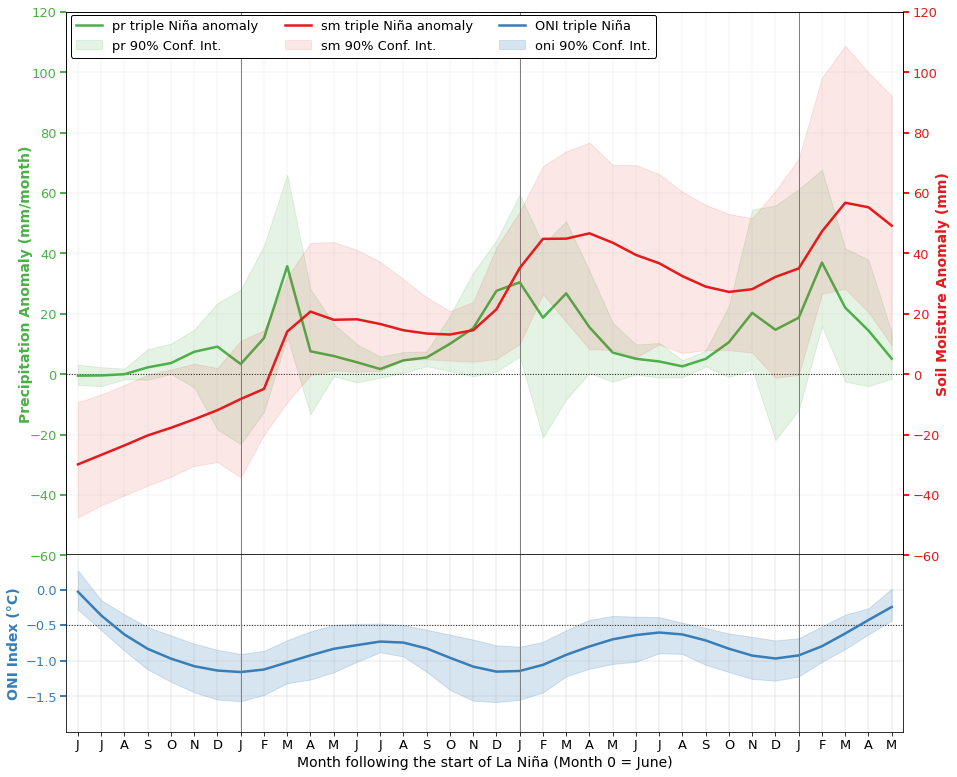

In [105]:
# --- 1. CALCUL DES LIMITES PROPORTIONNELLES ---
# On centre sur 0. On choisit des limites qui permettent de voir les anomalies clairement.
pr_min, pr_max = -60, 120  # Précipitations (mm/mois)
sm_min, sm_max = -60, 120   # Soil Moisture (mm)

fig, ax1 = plt.subplots(figsize=(15, 10))
months_labels = ['J','J','A','S','O','N','D','J','F','M','A','M'] * 3

color_pr = '#4daf4a' # Vert
color_sm = '#e41a1c' # Rouge
color_oni = '#377eb8' # Bleu

# --- 2. PRÉCIPITATIONS (Axe Gauche - Anomalies) ---
# Shading PR (Vert) autour de l'anomalie
ax1.fill_between(x, ci_pr_anom_low, ci_pr_anom_high, 
                 color=color_pr, alpha=0.15, zorder=1)

l1, = ax1.plot(x, mmm_pr_anom, color=color_pr, linewidth=2.5, label='pr triple Niña anomaly', zorder=5)

ax1.set_ylabel('Precipitation Anomaly (mm/month)', color=color_pr, fontsize=14, fontweight='bold', labelpad=-4)
ax1.tick_params(axis='y', labelcolor=color_pr, color=color_pr, labelsize=13, length=6, width=2)
ax1.set_ylim(pr_min, pr_max)
ax1.set_yticks([-60, -40, -20, 0, 20, 40, 60, 80, 100, 120])

# Grille et axes
ax1.set_xticks(np.arange(36))
ax1.set_xticklabels([]) 
ax1.grid(True, axis='both', linewidth=0.3, alpha=0.5)
ax1.axhline(0, color='black', linestyle=':', linewidth=1, zorder=1)

# --- 3. SOIL MOISTURE (Axe Droit - Anomalies) ---
ax2 = ax1.twinx()
# Shading SM (Rouge) autour de l'anomalie
ax2.fill_between(x, ci_sm_anom_low, ci_sm_anom_high, 
                 color=color_sm, alpha=0.1, zorder=1)

l2, = ax2.plot(x, mmm_sm_anom, color=color_sm, linewidth=2.5, label='sm triple Niña anomaly', zorder=5)

ax2.set_ylabel('Soil Moisture Anomaly (mm)', color=color_sm, fontsize=14, fontweight='bold', labelpad=-4)
ax2.tick_params(axis='y', labelcolor=color_sm, color=color_sm, labelsize=13, length=6, width=2)
ax2.set_ylim(sm_min, sm_max)
ax2.set_yticks([-60, -40, -20, 0, 20, 40, 60, 80, 100, 120])

# Séparateurs d'années (Juin à Mai)
for tick in [7, 19,31]:
    ax1.axvline(x=tick, color='gray', linewidth=1, linestyle='-')

# --- 4. ONI INDEX (Panel du bas) ---
pos = ax1.get_position()
ax3 = fig.add_axes([pos.x0, -0.12, pos.width, 0.247])

# Shading ONI (Bleu)
ax3.fill_between(x, ci_oni_low, ci_oni_high, 
                 color=color_oni, alpha=0.2, zorder=1)

l3, = ax3.plot(x, mmm_oni, color=color_oni, linewidth=2.5, label='ONI triple Niña')

ax3.set_ylabel('ONI Index (°C)', color=color_oni, fontsize=14, fontweight='bold')
ax3.tick_params(axis='y', labelcolor=color_oni, color=color_oni, labelsize=13, length=6, width=2)
ax3.set_ylim(-2, 0.5)
ax3.set_yticks([ 0.0, -0.5, -1.0, -1.5])

ax3.set_xticks(np.arange(36))
ax3.set_xticklabels(months_labels, fontsize=13)
ax3.set_xlabel('Month following the start of La Niña (Month 0 = June)', fontsize=14)
ax3.grid(True, linewidth=0.3)
ax3.axhline(-0.5, color='black', linestyle=':', linewidth=1, zorder=1)

for tick in [7, 19,31]:
    ax3.axvline(x=tick, color='gray', linewidth=1, linestyle='-')

# --- 5. LÉGENDE UNIFIÉE ET OPAQUE ---
patch_pr = mpatches.Patch(color=color_pr, alpha=0.15, label='pr 90% Conf. Int.')
patch_sm = mpatches.Patch(color=color_sm, alpha=0.1, label='sm 90% Conf. Int.')
patch_oni = mpatches.Patch(color=color_oni, alpha=0.2, label='oni 90% Conf. Int.')

all_handles = [l1, patch_pr, l2, patch_sm, l3, patch_oni]
legend = fig.legend(handles=all_handles, loc='upper left', 
                    bbox_to_anchor=(0.123, 0.885), ncol=3, 
                    fontsize=13, frameon=True, facecolor='white', framealpha=1, edgecolor='black')
margin = 0.5
for ax in [ax1, ax3]:
    ax.set_xlim(-margin, 35 + margin)

plt.savefig('/g/data/m35/qr1706/PhD-1_CMIP_analysis/png/sp_anom_36mth_sm_pr_oni.png', dpi=300, bbox_inches='tight', pad_inches=0.2, facecolor='white', edgecolor='none')
    
plt.show()

In [27]:
# 1. Définition des dimensions
seasons = ['JJA', 'SON', 'DJF', 'MAM']
variables = ['ONI (°C)', 'Precipitation anomaly (mm/m)', 'Soil Moisture anomaly (mm)']

# 2. Création du MultiIndex pour les colonnes (fusion automatique des titres)
columns = pd.MultiIndex.from_product([variables, ['Year 1', 'Year 2', 'Year 3']],
                                     names=['Variable', 'Year'])

# 3. Calcul et remplissage des données
data_rows = []
for s_idx, s_name in enumerate(seasons):
    row = []
    for var_name in variables:
        for yr in range(3):
            # Mapping temporel : Year 1 (0-11), Year 2 (12-23), Year 3 (24-35)
            start = (yr * 12) + (s_idx * 3)
            end = start + 3
            
            if var_name == 'ONI (°C)':
                val = mmm_oni[start:end].mean().item()
            elif var_name == 'Precipitation anomaly (mm/m)':
                val = mmm_pr[start:end].mean().item() - clim_pr_36[start:end].mean()
            else: # Soil Moisture anomaly (mm)
                val = mmm_sm[start:end].mean().item() - clim_sm_36[start:end].mean()
            row.append(val)
    data_rows.append(row)

# 4. Création du DataFrame final
df_final = pd.DataFrame(data_rows, index=seasons, columns=columns)

# 5. Application du style (ton rendu exact)
styled_table = df_final.style.format(precision=2)\
    .set_properties(**{
        'text-align': 'center',
        'padding': '12px',
        'border': '1px solid #ddd',
        'font-family': 'Arial, sans-serif'
    })\
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', 'white'), 
                                     ('color', '#2c3e50'), 
                                     ('font-weight', 'bold'),
                                     ('text-align', 'center'),
                                     ('border', '1px solid lightgrey')]},
        {'selector': 'th.row_heading', 'props': [('background-color', '#ecf0f1'), 
                                                ('color', '#2c3e50')]}
    ])\
    .set_properties(subset=['ONI (°C)'], **{'background-color': '#f0f7ff'})\
    .set_properties(subset=['Precipitation anomaly (mm/m)'], **{'background-color': '#f2fff2'})\
    .set_properties(subset=['Soil Moisture anomaly (mm)'], **{'background-color': '#fff5f5'})

#df_final.to_csv('/g/data/m35/qr1706/PhD-1_CMIP_analysis/png/Model_by_Model/SP_models_triple_lanina_results_median.csv')
# Affichage
display(styled_table)

In [106]:
# --- CONFIGURATION ---
season_months = {'JJA': [6, 7, 8], 'SON': [9, 10, 11], 'DJF': [12, 1, 2], 'MAM': [3, 4, 5]}

# --- PRÉPARATION DES MMM (MULTI-MODEL MEAN) ---
# 1. Les anomalies Triple La Niña (Lignes pleines)
all_ev_pr = [item for sublist in results_pr.values() for item in sublist]
mmm_pr = xr.concat(all_ev_pr, dim='event').mean('event')

all_ev_sm = [item for sublist in results_sm.values() for item in sublist]
mmm_sm = xr.concat(all_ev_sm, dim='event').mean('event')

all_ev_oni = [item for sublist in results_oni.values() for item in sublist]
mmm_oni = xr.concat(all_ev_oni, dim='event').mean('event')

# 2. Les cycles de référence historiques (Lignes pointillés)
mmm_clim_pr_cycle = xr.concat(list(clims_pr.values()), dim='model').mean('model')
mmm_clim_sm_cycle = xr.concat(list(clims_sm.values()), dim='model').mean('model')

# 3. Les baselines physiques (Dénominateur absolu)
mmm_seasonal_abs_pr = xr.concat(list(seasonal_abs_pr.values()), dim='model').mean('model')
mmm_seasonal_abs_sm = xr.concat(list(seasonal_abs_sm.values()), dim='model').mean('model')

In [107]:
# 1. Définition des dimensions (Noms mis à jour pour les unités %)
seasons = ['JJA', 'SON', 'DJF', 'MAM']
variables = ['ONI Index (°C)', 'Precipitation anomaly (%)', 'Soil Moisture anomaly (%)']

# 2. Création du MultiIndex pour les colonnes
columns = pd.MultiIndex.from_product([variables, ['Year 1', 'Year 2', 'Year 3']],
                                     names=['Variable', 'Year'])

# 3. Calcul et remplissage des données
data_rows = []
for s_idx, s_name in enumerate(seasons):
    row = []
    months = season_months[s_name]
    
    # Récupération des baselines et références pour la saison
    base_pr_s = mmm_seasonal_abs_pr.sel(month=months).mean().item()
    base_sm_s = mmm_seasonal_abs_sm.sel(month=months).mean().item()
    ref_pr_s = mmm_clim_pr_cycle.sel(month=months).mean().item()
    ref_sm_s = mmm_clim_sm_cycle.sel(month=months).mean().item()

    for var_name in variables:
        for yr in range(3):
            start = (yr * 12) + (s_idx * 3)
            end = start + 3
            
            if 'ONI' in var_name:
                val = mmm_oni[start:end].mean().item()
            elif 'Precipitation' in var_name:
                # Formule : (Niña - Pointillé) / Physique * 100
                val_nina = mmm_pr[start:end].mean().item()
                val = ((val_nina - ref_pr_s) / base_pr_s) * 100
            else: # Soil Moisture
                val_nina = mmm_sm[start:end].mean().item()
                val = ((val_nina - ref_sm_s) / base_sm_s) * 100
                
            row.append(val)
    data_rows.append(row)

# 4. Création du DataFrame final
df_final_pct = pd.DataFrame(data_rows, index=seasons, columns=columns)

# 5. Application du style (ton rendu exact avec les nouvelles variables)
styled_table = df_final_pct.style.format(precision=2)\
    .set_properties(**{
        'text-align': 'center',
        'padding': '12px',
        'border': '1px solid #ddd',
        'font-family': 'Arial, sans-serif'
    })\
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', 'white'), 
                                     ('color', '#2c3e50'), 
                                     ('font-weight', 'bold'),
                                     ('text-align', 'center'),
                                     ('border', '1px solid lightgrey')]},
        {'selector': 'th.row_heading', 'props': [('background-color', '#ecf0f1'), 
                                                 ('color', '#2c3e50')]}
    ])\
    .set_properties(subset=['ONI Index (°C)'], **{'background-color': '#f0f7ff'})\
    .set_properties(subset=['Precipitation anomaly (%)'], **{'background-color': '#f2fff2'})\
    .set_properties(subset=['Soil Moisture anomaly (%)'], **{'background-color': '#fff5f5'})

#df_final_pct.to_csv('/g/data/m35/qr1706/PhD-1_CMIP_analysis/png/%triple_lanina_results_median.csv')
# Affichage
display(styled_table)

In [15]:
import xarray as xr
import numpy as np
from scipy import stats

def prepare_mme_arrays(results_dict):
    """
    Concatène tous les événements de tous les modèles en un seul DataArray.
    Shape finale : (n_total_events, 36)
    """
    all_events = []
    for model_name in results_dict.keys():
        # results_dict[model_name] est une liste de DataArrays de 36 mois
        model_data = xr.concat(results_dict[model_name], dim='event')
        all_events.append(model_data)
    
    # Fusion de tous les modèles
    mme_da = xr.concat(all_events, dim='event')
    return mme_da

# Création des cubes de données MME (Shape: event=N, time=36)
da_pr_mme = prepare_mme_arrays(results_pr)
da_sm_mme = prepare_mme_arrays(results_sm)

print(f"Total d'événements Triple La Niña cumulés : {da_pr_mme.shape[0]}")

Total d'événements Triple La Niña cumulés : 122


In [16]:
def compute_cross_correlation_mme(da_pr, da_sm):
    # Lags de -4 (Mai Y+1) à 7 (Juin Y0). 0 = Janvier Y1.
    lags = np.arange(-4, 8) 
    # Correspondance indices dans le bloc 36 mois (débuté en Juin)
    # Janvier Year 1 = index 7 | Janvier Year 2 = index 19 | Janvier Year 3 = index 31
    jan_indices = [7, 19, 31]
    labels = ['Year 1', 'Year 2', 'Year 3']
    
    final_results = {}

    for jan_idx, label in zip(jan_indices, labels):
        corrs = []
        p_vals = []
        
        # 1. Cible : Moyenne PR DJF pour cette phase
        # On prend Dec (jan-1), Jan, Feb (jan+1)
        target_pr = da_pr.isel(time=[jan_idx-1, jan_idx, jan_idx+1]).mean(dim='time')
        
        for l in lags:
            # 2. Variable : SM au mois (Janvier - l)
            predictor_sm = da_sm.isel(time=jan_idx - l)
            
            # 3. Calcul stat (Pearson) entre les vecteurs d'événements
            r, p = stats.pearsonr(target_pr.values, predictor_sm.values)
            corrs.append(r)
            p_vals.append(p)
            
        final_results[label] = {'r': corrs, 'p': p_vals}
    
    # 4. Climatologie (Moyenne des r des 3 phases)
    final_results['Climatology'] = np.nanmean([final_results[l]['r'] for l in labels], axis=0)
    
    return lags, final_results

# Exécution
lags_x, cross_corrs = compute_cross_correlation_mme(da_pr_mme, da_sm_mme)

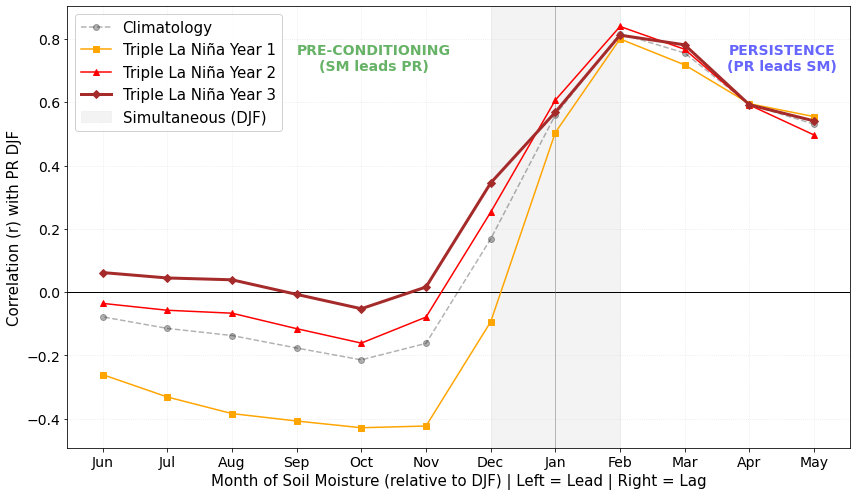

In [28]:
plt.figure(figsize=(12, 7))

# 1. Climatologie
plt.plot(lags_x, cross_corrs['Climatology'], color='black', ls='--', marker='o', alpha=0.3, label='Climatology')

# 2. Triple Niña
colors = ['orange', 'red', 'brown']
markers = ['s', '^', 'D']

for i, yr in enumerate(['Year 1', 'Year 2', 'Year 3']):
    r_values = cross_corrs[yr]['r']
    p_values = cross_corrs[yr]['p']
    
    # Plot principal
    plt.plot(lags_x, r_values, color=colors[i], marker=markers[i], 
             lw=3 if i==2 else 1.5, label=f'Triple La Niña {yr}', zorder=5 if i==2 else 3)

# --- MISE EN PAGE ---
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='grey', lw=1, alpha=0.5)

# Zone DJF (Janvier +/- 1 mois)
plt.axvspan(-1, 1, color='#F0F0F0', alpha=0.8, label='Simultaneous (DJF)', zorder=1)

# Inversion de l'axe : Passé à gauche, Futur à droite
plt.gca().invert_xaxis() 

# Labels des mois (J J A S O N D [J] F M A)
month_labels = ['May', 'Apr', 'Mar', 'Feb', 'Jan', 'Dec', 'Nov', 'Oct', 'Sep', 'Aug', 'Jul', 'Jun']
plt.xticks(lags_x, month_labels, fontsize=14) 
plt.yticks(fontsize=14) 

plt.xlabel("Month of Soil Moisture (relative to DJF) | Left = Lead | Right = Lag", fontsize=15)
plt.ylabel("Correlation (r) with PR DJF", fontsize=15)
#plt.title("CMIP6 Multi-Model Ensemble: Lead-Lag Relationship (SM vs DJF Monsoon)", fontsize=14)

# Annotations
plt.text(2.8, 0.7, "PRE-CONDITIONING\n(SM leads PR)", color='green', fontweight='bold', fontsize=14, ha='center', alpha=0.6)
plt.text(-3.5, 0.7, "PERSISTENCE\n(PR leads SM)", color='blue', fontweight='bold', fontsize=14, ha='center', alpha=0.6)

plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9, fontsize=15)
plt.grid(True, ls=':', alpha=0.3)
plt.tight_layout()

plt.savefig('/g/data/m35/qr1706/PhD-1_CMIP_analysis/png/CMIP6_Lead-Lag_MME_SM_PR_DJF_notitle.png', dpi=600)
plt.show()